In [ ]:
from analyzer import * 
import pandas as pd
import matplotlib.pyplot as plt
from utils.df import parse_ci 
from utils.corr import get_model_corr, human_vs_consensus, corr_by_regime, pairwise_metric, bootstrap_spearman
from utils.plots import scatterplot_finetuned # scatterplot, plot_unified_agreement_heatmap, get_family, parse_size  

sns.set_style('whitegrid') 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [322]:
mm = MMStarResults()
# answers_pivot = mm.combine_mh(model_acc=mm.model_mc) 
md = mm.model_mc 
md=md[md['condition'] == 'inst blind']
vlms=md[md['model_type'] != 'llm'].model.unique() 
llms=md[md['model_type'] == 'llm'].model.unique() 
all_humans = mm.human.participant_id.unique()   
md.finetuned.unique()  

/home/work/yuna/HPA/evaluation/analysis/analyzer.py:143: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.human['correct'] = self.human['correct'] * 100


14 6
[]


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:177: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df['category'].map(mmstar_cat_map)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:178: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['question_id'] = df['question_id'].astype('Int64')


array(['Pretrained', 'JS VQA (GT)', 'SFT-Blind MMStar (n=15)',
       'JS-Blind VQA (n=10)', 'JS-Blind VQA (n=15)',
       'JS-Blind MMStar (n=15)', 'SFT-Blind VQA', 'SFT-VQA',
       'SFT-Blind MMStar'], dtype=object)

In [353]:
hm_acc = mm.human.groupby([ 'category', 'l2_category', 'question_id'])['correct'].mean().reset_index()
alignment_results = []
n_boot = 1000

for vlm in md.model.unique() : 

    hm = pd.merge(hm_acc, md[md['model'] == vlm], 
                    on=['category', 'l2_category', 'question_id'], 
                    how='inner',
                    suffixes=("_human", '_model'))  

    for ft in hm.finetuned.unique(): 
        theta_hat = pairwise_metric(hm[hm['finetuned']==ft]['correct_model'].values, 
                                    hm[hm['finetuned']==ft]['correct_human'].values )  
        
        if n_boot: 
            boot =  bootstrap_spearman(hm[hm['finetuned']==ft]['correct_model'].values, hm[hm['finetuned']==ft]['correct_human'].values, n_boot, 42) 
            ci = np.percentile(boot, [2.5, 97.5]) # 95% percentile CI

        alignment_results.append({
            'model': vlm, 
            'theta_hat': theta_hat, 
            "ci": ci,
            "finetuned": ft, 
            # 'data': hm 
        }) 

In [357]:
df = pd.DataFrame(alignment_results) 
### Filter invalid model 
df = df[df['model'] != 'Qwen3 Base (8B)' ]
# df = df[df['finetuned'] == 'Pretrained']
df['dataset'] = "MMStar"

ci_lows = np.array([c[0] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
ci_highs = np.array([c[1] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

models = df.model.values # list(alignment_results.keys())
rhos = df.theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])

human_correct =mm.human.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct = (human_correct > 0).astype(int)
human_rhos = human_vs_consensus(human_correct) 
low, high = np.percentile(human_rhos, [2.5, 97.5])
mu, sd = human_rhos.mean(), human_rhos.std() 
human_correct.shape , mu, sd 

((20, 247), 0.290796260316054, 0.09906076795651508)

In [358]:
# Example: Add a new row with sample values. You can adjust the values as needed.
new_row = {
    'model': 'humans',
    'theta_hat': mu,
    'ci': [low, high],
    'finetuned': 'humans',
    'dataset': 'MMStar'
}
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df = df.dropna(axis=0) 
df.to_json('./correlations/mmstar.json')
df

,model,theta_hat,ci,finetuned,dataset
0,InternVL 3.5 (1B),0.127259,"[0.01807723636027576, 0.24007046518527747]",Pretrained,MMStar
1,InternVL 3.5 (2B),0.182182,"[0.06843183181116226, 0.2951462527712584]",Pretrained,MMStar
2,InternVL 3.5 (4B),0.118522,"[-0.012406274713037126, 0.23398128087226605]",Pretrained,MMStar
3,InternVL 3.5 (8B),0.230196,"[0.11117597332303726, 0.33979072431682805]",Pretrained,MMStar
4,InternVL 3.5 (8B),0.200721,"[0.07695275104800336, 0.3204019650183335]",JS VQA (GT),MMStar
5,InternVL 3.5 (8B),0.258897,"[0.14586402843301557, 0.3595749240506157]",SFT-Blind MMStar (n=15),MMStar
6,InternVL 3.5 (8B),0.272275,"[0.16303810351636416, 0.3816517808137501]",JS-Blind VQA (n=10),MMStar
7,InternVL 3.5 (8B),0.270328,"[0.16464508215591736, 0.38246825038229476]",JS-Blind VQA (n=15),MMStar
8,InternVL 3.5 (8B),0.294459,"[0.186708144900753, 0.39534954344176865]",JS-Blind MMStar (n=15),MMStar
9,InternVL 3.5 (8B),0.269664,"[0.1603890305172797, 0.38562786480254263]",SFT-Blind VQA,MMStar


In [326]:
md.condition.unique()

array(['inst blind'], dtype=object)

In [327]:
md.groupby(['category'])['correct'].mean()

category
coarse perception          26.238390
fine-grained perception    28.322043
instance reasoning         26.842105
logical reasoning          42.105263
science & technology       28.947368
Name: correct, dtype: float64

In [328]:
mm.human.groupby(['category'])['correct'].mean() 

category
coarse perception          28.182487
fine-grained perception    26.287129
instance reasoning         28.727273
logical reasoning          28.701595
science & technology       10.000000
Name: correct, dtype: float64

In [ ]:
df = pd.read_json('./correlations/mmstar_pretrained.json') 

## VQA 

In [566]:
vv = VQAResults()   
human_vqa = vv.human.drop_duplicates(subset=['question_id', 'participant_id']) 
# get_agreements(human_vqa, model_vqa, metrics="correct", n_boot=200) 
model_vqa = vv.model  # only the blind condition 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
before 38.98698056001426
after  39.8876404494382
14 6
[]
before 56.03892348105268
after  56.19256133352792
[]
before 56.54445633752563
after  56.68585294518072


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)


processed_ans                                 1
correct                                   100.0
gt_answers       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Name: 6424, dtype: object

#### VQA correlations 
df: alignment_results 

In [ ]:
human_correct_vqa = human_vqa.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct_vqa = (human_correct_vqa > 0).astype(int)
human_rhos_vqa = human_vs_consensus(human_correct_vqa) 
low_vqa, high_vqa = np.percentile(human_rhos_vqa, [2.5, 97.5])  
mu_vqa, sd_vqa = human_rhos_vqa.mean(), human_rhos_vqa.std()   
new_row = {
    'model': 'humans',
    'theta_hat': mu_vqa,
    'ci': [low_vqa, high_vqa],
    'finetuned': 'humans',
    'dataset': 'VQA', 
    'metric': 'correct'
}
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df   

In [599]:
# hm_sim = mm.human.groupby(['question_id'])[''].mean().values
hm_acc = human_vqa.groupby(['answer_type', 'question_type', 'question_id'])[['correct', 'answer_similarity']].mean().reset_index()
alignment_results = []
n_boot = 1000 
for metric in ['answer_similarity', 'correct']:
    for vlm in model_vqa.model.unique():
        for ft in model_vqa.finetuned.unique():

            hm = pd.merge(
                hm_acc,
                model_vqa[
                    (model_vqa['model'] == vlm) &
                    (model_vqa['finetuned'] == ft)
                ],
                on=['answer_type', 'question_type', 'question_id'],
                how='inner',
                suffixes=("_human", "_model")
            )

            if len(hm) < 3:
                continue

            theta_hat = pairwise_metric(
                hm[f'{metric}_model'].values,
                hm[f'{metric}_human'].values
            )

            ci = None
            if n_boot:
                boot = bootstrap_spearman(
                    hm[f'{metric}_model'].values,
                    hm[f'{metric}_human'].values,
                    n_boot,
                    42
                )
                ci = np.percentile(boot, [2.5, 97.5])

            alignment_results.append({
                'model': vlm,
                'theta_hat': theta_hat,
                'ci': ci,
                'metric': metric,
                'finetuned': ft
            })
vqa = pd.DataFrame(alignment_results) 
vqa['dataset'] = 'VQA'

In [604]:
corr = pd.concat([df, vqa.dropna(axis=0)])  
# vqa.to_json('./correlations/vqa.json')  
corr = corr.dropna(subset=['theta_hat'], axis=0).fillna('correct')
corr['ci'] = corr['ci'].apply(parse_ci)
corr['ci_low'] = corr['ci'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 2 else np.nan
)

corr['ci_high'] = corr['ci'].apply(
    lambda x: x[1] if isinstance(x, list) and len(x) == 2 else np.nan
)
corr[corr['model'] == 'humans']  
corr 

,model,theta_hat,ci,finetuned,dataset,metric,ci_low,ci_high
0,InternVL 3.5 (1B),0.127259,"[0.01807723636027576, 0.24007046518527747]",Pretrained,MMStar,correct,0.018077,0.240070
1,InternVL 3.5 (2B),0.182182,"[0.06843183181116226, 0.2951462527712584]",Pretrained,MMStar,correct,0.068432,0.295146
2,InternVL 3.5 (4B),0.118522,"[-0.012406274713037126, 0.23398128087226605]",Pretrained,MMStar,correct,-0.012406,0.233981
3,InternVL 3.5 (8B),0.230196,"[0.11117597332303726, 0.33979072431682805]",Pretrained,MMStar,correct,0.111176,0.339791
4,InternVL 3.5 (8B),0.200721,"[0.07695275104800336, 0.3204019650183335]",JS VQA (GT),MMStar,correct,0.076953,0.320402
...,...,...,...,...,...,...,...,...
69,LLaVA‑Mistral (7B),0.600443,"[0.5336464334525336, 0.6660674282519328]",SFT-Blind MMStar,VQA,correct,0.533646,0.666067
70,Qwen3 (8B),0.528730,"[0.4509974863957453, 0.59826400178314]",Pretrained,VQA,correct,0.450997,0.598264
71,LLaVA‑1.5 (7B),0.492477,"[0.41363835774003166, 0.5711132777158656]",Pretrained,VQA,correct,0.413638,0.571113
72,Qwen3 (4B),0.533855,"[0.3463365251398459, 0.6793591265741383]",Pretrained,VQA,correct,0.346337,0.679359


In [12]:
df = pd.read_json('./correlations/vqa.json') 

### Human reference 

In [605]:
pretrained_corr = corr[corr['finetuned'] == "Pretrained"]
pivoted = pretrained_corr.pivot(index=['model'], columns=['dataset', 'metric'], values=['theta_hat', 'ci_low', 'ci_high'])
# pivoted = pivoted.sort_values(     by=('theta_hat', 'VQA', 'correct'),     ascending=False )
model_order = pivoted.index.unique().to_numpy()   
pivoted

theta_hat                                ci_low  \
dataset               MMStar               VQA              MMStar   
metric               correct answer_similarity   correct   correct   
model                                                                
InternVL 3.5 (1B)   0.127259          0.664377  0.641616  0.018077   
InternVL 3.5 (2B)   0.182182          0.681664  0.625079  0.068432   
InternVL 3.5 (4B)   0.118522          0.683680  0.668535 -0.012406   
InternVL 3.5 (8B)   0.230196          0.700911  0.676487  0.111176   
LLaVA‑1.5 (7B)      0.143540          0.604789  0.492477  0.030645   
LLaVA‑Mistral (7B)  0.149260          0.596037  0.500952  0.033723   
LLaVA‑Vicuna (7B)   0.128955          0.605526  0.489037  0.024459   
Qwen3 (4B)          0.187189          0.451237  0.533855  0.067117   
Qwen3 (8B)          0.212462          0.449864  0.528730  0.091079   
Qwen3‑VL (2B)       0.093417          0.641445  0.555205 -0.034310   
Qwen3‑VL (4B)       0.172121          0.616361  0.613313  0.051727   
Qwen3‑VL (8B)       0.203158          0.670712  0.633641  0.076883   

                                                 ci_high                    \
dataset                          VQA              MMStar               VQA   
metric             answer_similarity   correct   correct answer_similarity   
model                                                                        
InternVL 3.5 (1B)           0.591448  0.580773  0.240070          0.728513   
InternVL 3.5 (2B)           0.612039  0.561529  0.295146          0.739972   
InternVL 3.5 (4B)           0.611888  0.601369  0.233981          0.741004   
InternVL 3.5 (8B)           0.633671  0.608956  0.339791          0.761367   
LLaVA‑1.5 (7B)              0.527625  0.413638  0.272185          0.676010   
LLaVA‑Mistral (7B)          0.509845  0.422697  0.272649          0.672063   
LLaVA‑Vicuna (7B)           0.521313  0.407299  0.232539          0.680738   
Qwen3 (4B)                  0.201243  0.346337  0.300900          0.650522   
Qwen3 (8B)                  0.350390  0.450997  0.315456          0.536423   
Qwen3‑VL (2B)               0.560143  0.478397  0.203590          0.708334   
Qwen3‑VL (4B)               0.533892  0.544051  0.293865          0.690398   
Qwen3‑VL (8B)               0.593119  0.569593  0.320703          0.734668   

                              
dataset                       
metric               correct  
model                         
InternVL 3.5 (1B)   0.698148  
InternVL 3.5 (2B)   0.685617  
InternVL 3.5 (4B)   0.723515  
InternVL 3.5 (8B)   0.734772  
LLaVA‑1.5 (7B)      0.571113  
LLaVA‑Mistral (7B)  0.580362  
LLaVA‑Vicuna (7B)   0.576727  
Qwen3 (4B)          0.679359  
Qwen3 (8B)          0.598264  
Qwen3‑VL (2B)       0.621593  
Qwen3‑VL (4B)       0.680087  
Qwen3‑VL (8B)       0.690054

In [ ]:

mu, low, high = corr[(corr['model'] == 'humans') & (corr['dataset'] != 'MMStar')].iloc[0][['theta_hat', 'ci_low', 'ci_high']]  
mu_mm, low_mm, high_mm = corr[(corr['model'] == 'humans') & (corr['dataset'] == 'MMStar')].iloc[0][['theta_hat', 'ci_low', 'ci_high']] 
len(model_order), len(rhos_mm), len(ci_lows_mm), len(ci_highs_mm)
len(rhos_acc), len(ci_lows_acc), len(ci_highs_acc) , len(rhos_sim), len(ci_lows_sim), len(ci_highs_sim)  

(12, 12, 12, 12, 12, 12)

In [589]:
corr[(corr['model'] == 'humans') & (corr['dataset'] != 'MMStar') & (corr['metric'] == 'correct')].iloc[0][['theta_hat', 'ci_low', 'ci_high']]  

theta_hat    0.724045
ci_low       0.630073
ci_high      0.791041
Name: 39, dtype: object

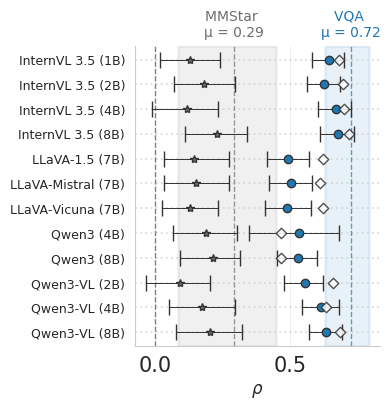

In [593]:
# from utils.plots import plot_model_corr 

fig, ax = plt.subplots(figsize=(4, 0.35 * len(model_order))) # figsize=(6, 3 + 0.4 * len(models)))  
# ax.set_xlim(-0.1, 0.45)

ax = plot_model_corr(ax, rhos_mm, ci_lows_mm, ci_highs_mm, model_order, 
                    low_mm, high_mm, mu_mm, dataset="MMStar", color="#6E6E6E", marker='*')

ax = plot_model_corr(ax, rhos_acc, ci_lows_acc, ci_highs_acc, model_order, 
                    low, high, mu, dataset="VQA", color="#1f77b4", marker='o')    
ax.scatter(
    rhos_sim + 0.015,  # small horizontal separation,
    np.arange(len(model_order) ),
    marker="D",
    s=28,
    facecolors="white",
    edgecolors="#333333",
    linewidths=1,
    label="Answer similarity",
    alpha=0.85, 
    zorder=5   
)
ax.set_yticklabels(model_order, fontsize=9)
ax.axvline( 0,  color="gray",linestyle="--",linewidth=1 ) ## Reference line at rho = 0  
ax.grid(axis="y", linestyle=":" , linewidth=1.4 , alpha=0.6 )
ax.grid(axis="x", alpha=0.3)  # ax.grid(False, axis="x")  
ax.set_xlabel(r"$\rho$", fontsize=12) #  (Spearman correlation to human consensus) 
ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(model_order) 
ax.invert_yaxis() 
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False) # Clean spines 

# ax.legend(  loc="lower left",     frameon=True,     fontsize=10, )
# plt.title("Model–Human Alignment") 
plt.tight_layout()
plt.show() 

## MG Scatterplots 

In [624]:
sim_mg = vv.test_model_mg_sim.groupby(['model', 'finetuned'])['MG'].mean().reset_index()
acc_mg = vv.test_model_mg_acc.groupby(['model', 'finetuned'])['MG'].mean().reset_index() # .dropna(axis=1).groupby(['model', 'finetuned']).mean(numeric_only=True)
vqa_mg = pd.merge(sim_mg, acc_mg, suffixes=('_sim', '_acc'), how='inner', on=['model', 'finetuned'])
vqa_mg['family'] = vqa_mg['model'].map(get_family)
vqa_mg['model_size'] = vqa_mg['model'].map(parse_size)      


finetuned_list = ['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=15)', 'SFT-Blind VQA',  'SFT-VQA'] 
pcorr = pd.merge(corr[corr['metric'] == 'correct'], vqa_mg, on=['model', 'finetuned']) 
pcorr = pcorr[pcorr['finetuned'].isin(finetuned_list)] # ,'JS-Blind VQA (n=10)', 'SFT-Blind MMStar', 'JS-Blind MMStar (n=15)',  

sim_corr = pd.merge(corr[corr['metric'] == 'answer_similarity'], vqa_mg, on=['model', 'finetuned']) 
sim_corr = sim_corr[sim_corr['finetuned'].isin(finetuned_list)] # ,'JS-Blind VQA (n=10)', 'SFT-Blind MMStar', 'JS-Blind MMStar (n=15)',  

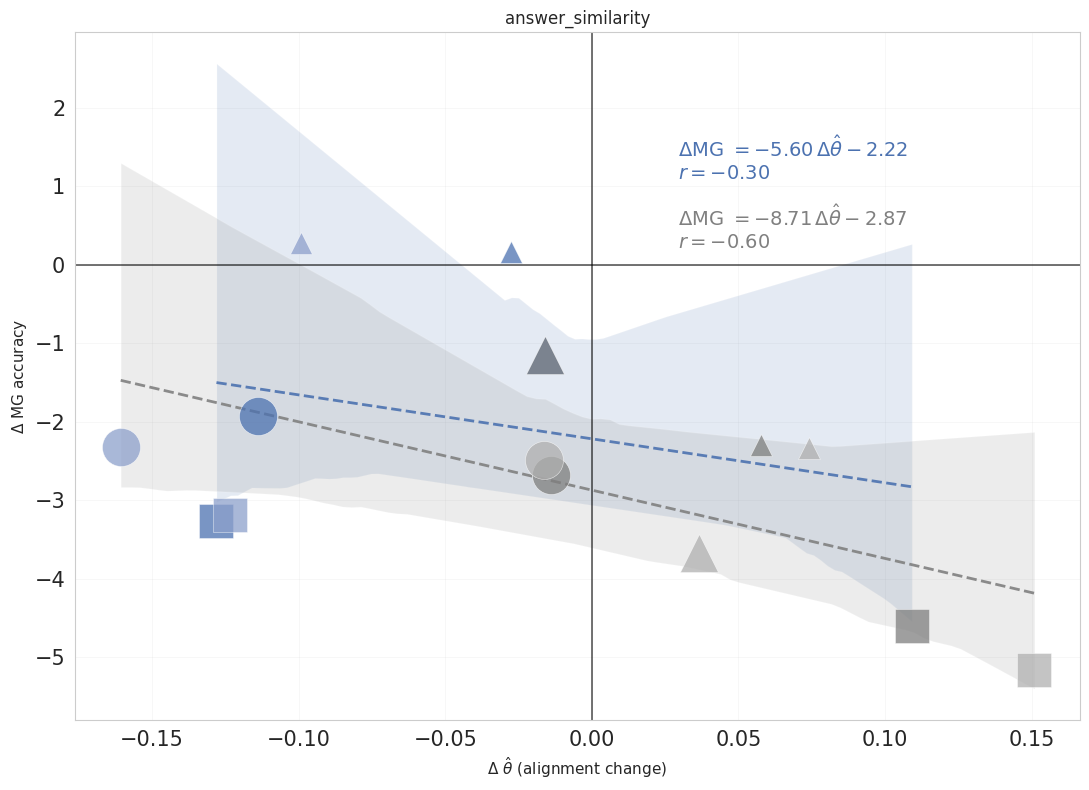

In [641]:
from scipy import stats
# from utils.plot_corr import * 

x_col = "theta_hat"
y_col = "MG_sim" 
delta_df = get_delta_df(sim_corr) 
regression_stats = get_stats(delta_df) 

scatterplot_delta_alignment_vs_mg(
    delta_df,
    regression_stats= regression_stats, 
    title = 'answer_similarity',
    EQ_POS = {
    "JS":  (0.6, 0.85),
    "SFT": (0.6, 0.75),
    }, 
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers, 
    figsize=(11,8) ) 

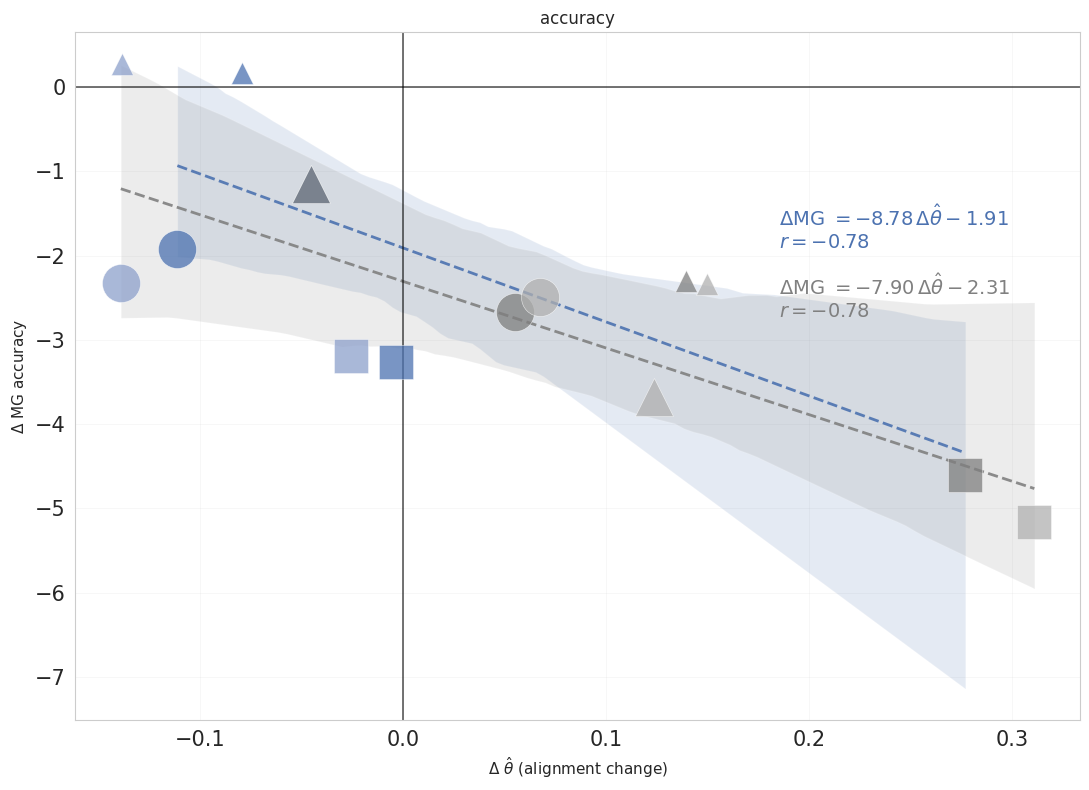

In [643]:
x_col = "theta_hat"
y_col = "MG_acc" 
delta_df = get_delta_df(pcorr[pcorr['dataset'] == 'VQA'])

scatterplot_delta_alignment_vs_mg(
    delta_df,
    title = 'accuracy',
    regression_stats = get_stats(delta_df), 
    EQ_POS= {
    "JS":  (0.7, 0.75),
    "SFT": (0.7, 0.65),
    }, 
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers ,
    figsize=(11,8) ) 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd 
from matplotlib.lines import Line2D 

JS_REGIMES  = ["JS VQA (GT)", "JS-Blind VQA (n=15)"]
SFT_REGIMES = ["SFT-Blind VQA", "SFT-VQA"] 
REGIME_GROUPS = {
    "JS":  JS_REGIMES,
    "SFT": SFT_REGIMES,
}
regime_colors  = {
    # Ground‑truth supervised (blue family)
    "JS VQA (GT)":  "#4C72B0",  # darker muted blue
    "SFT-VQA":      "#8DA0CB",  # lighter blue

    # Blind training (gray family)
    "JS-Blind VQA (n=15)": "#7F7F7F",  # darker gray
    "SFT-Blind VQA":       "#B0B0B0",  # lighter gray
}
REGIME_LINESTYLE = {'JS': {'color': '#4C72B0', 'linestyle': '--'},
                    'SFT': {'color': "gray", 'linestyle': '--'}}  # '#DD8452' 
family_markers = {
    'InternVL': 'o', 
    'LLaVA': 's', 
    'Qwen': '^',
    'BLIP': '^',  
}
family_colors = {
    "InternVL": "#4C72B0",        # muted blue
    "LLaVA":    "#DD8452",        # muted orange
    "Qwen":     "#55A868",        # muted green
    "BLIP":     "#C44E52",        # muted red
}

regime_markers = {
    'Pretrained': 'o', 
    'JS VQA (GT)': 's', 
    'SFT-VQA': 's',
    'JS-Blind VQA (n=15)': '^',  
    'SFT-Blind VQA': '^', 
}


def get_stats(delta_df): 
    regression_stats = {}
    for regime, labels in REGIME_GROUPS.items():
        data = delta_df[delta_df["finetuned"].isin(labels)]
        if len(data) < 3:
            continue

        x = data["delta_theta"].to_numpy()
        y = data["delta_mg"].to_numpy()

        slope, intercept, r_val, _, _ = stats.linregress(x, y)
        rho, _ = stats.spearmanr(x, y)

        regression_stats[regime] = {
            "slope": slope,
            "intercept": intercept,
            "r": r_val,
            "rho": rho,
        } 
    return regression_stats 

def get_delta_df(df): 
    delta_rows = []

    for fam in df["family"].unique():
        fam_data = df[df["family"] == fam]

        for _, fin in fam_data[fam_data["finetuned"] != "Pretrained"].iterrows():
            pre = fam_data[
                (fam_data["model"] == fin["model"]) &
                (fam_data["finetuned"] == "Pretrained")
            ]
            if pre.empty:
                continue

            pre = pre.iloc[0]

            delta_rows.append({
                "family": fam,
                "model": fin["model"],
                "finetuned": fin["finetuned"],
                "delta_theta": fin["theta_hat"] - pre["theta_hat"],
                "delta_mg": fin["MG_acc"] - pre["MG_acc"],
                "model_size": fin["model_size"],
            })

    delta_df = pd.DataFrame(delta_rows)
    size_vals = delta_df["model_size"].astype(float)
    size_norm = (size_vals - size_vals.min()) / (size_vals.max() - size_vals.min() + 1e-6)
    delta_df["_size_norm"] = 0.5 + size_norm
    return delta_df 

def scatterplot_delta_alignment_vs_mg(
    delta_df,
    title,
    colors,          # keyed by finetuned regime
    markers,         # keyed by family (or regime if you prefer)
    regression_stats,
    EQ_POS, 
    size_scale=500,
    figsize=(12, 7),
):
    fig, ax = plt.subplots(figsize=figsize)
    # --------------------------------------------------
    # Regression per regime group
    # --------------------------------------------------
    for regime, labels in REGIME_GROUPS.items():
        data = delta_df[delta_df["finetuned"].isin(labels)]
        if len(data) < 3:
            continue

        sns.regplot(
            data=data,
            x="delta_theta",
            y="delta_mg",
            scatter=False,
            ci=68,
            # n_boot=200,          # ✅ bootstrap
            truncate=True,        # ✅ KEY FIX
            ax=ax,
            line_kws=dict(
                linewidth=2.0,
                alpha=0.9,
                zorder=2,
                **REGIME_LINESTYLE[regime],
            ),
        )
    for regime, stats_ in regression_stats.items():
        slope = stats_["slope"]
        intercept = stats_["intercept"]
        r_val = stats_["r"]

        eq_text = (
            rf"$\Delta$MG $= {slope:.2f}\,\Delta\hat{{\theta}} {intercept:+.2f}$" "\n"
            rf"$r = {r_val:.2f}$"
        )

        ax.text(
            EQ_POS[regime][0],
            EQ_POS[regime][1],
            eq_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=14,
            color=REGIME_LINESTYLE[regime]["color"],
            # alpha=0.9,
        )
    # --------------------------------------------------
    # Scatter points
    # --------------------------------------------------
    used_regime_labels = set()

    for _, row in delta_df.iterrows():
        reg = row["finetuned"]
        fam = row["family"]

        show_regime = reg not in used_regime_labels

        ax.scatter(
            row["delta_theta"],
            row["delta_mg"],
            s=row["_size_norm"] * size_scale,
            color=colors[reg],
            marker=markers[fam],
            alpha=0.75,
            edgecolors="white",
            linewidth=0.4,
            zorder=3,
            label=reg if show_regime else None,
        )

        if show_regime:
            used_regime_labels.add(reg)
    ax.axhline(0, color="black", lw=1.1, alpha=0.7)
    ax.axvline(0, color="black", lw=1.1, alpha=0.7)

    # --------------------------------------------------
    # Labels, title, legend
    # --------------------------------------------------
    ax.set_xlabel(r"$\Delta\ \hat{\theta}$ (alignment change)", fontsize=11)
    ax.set_ylabel(r"$\Delta$ MG accuracy", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(
        True,
        which="major",
        linewidth=0.5,
        alpha=0.2,
    )
    ax.set_axisbelow(True)
    handles, labels = ax.get_legend_handles_labels()
    desired_order = ['JS VQA (GT)', 'SFT-VQA', 'JS-Blind VQA (n=15)', 'SFT-Blind VQA']
    order = [labels.index(reg) for reg in desired_order if reg in labels]
    ordered_handles = [handles[idx] for idx in order]
    ordered_labels = [labels[idx] for idx in order]

    regime_handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=regime_colors[reg],
            markeredgecolor='white',
            markeredgewidth=0.6,
            markersize=9,
            label=reg,
        )
        for reg in ['JS VQA (GT)', 'SFT-VQA',
                    'JS-Blind VQA (n=15)', 'SFT-Blind VQA']
    ]

    leg1 = ax.legend(
        handles=regime_handles,
        title="Training regime",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        fontsize=11,
        frameon=True,
    )

    ax.add_artist(leg1)  # ✅ CRITICAL

    family_handles = [
        Line2D(
            [0], [0],
            marker=family_markers[fam],
            linestyle='None',
            color='black',
            markersize=9,
            label=fam,
        )
        for fam in family_markers
    ]

    ax.legend(
        handles=family_handles,
        title="Model family",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.32),
        ncol=4,
        fontsize=11,
        frameon=False,
    )
    plt.tight_layout()
    plt.show()